# Motion Capture Auto-Label Tracker

Load a TSV clip and a skeleton graph (`mocap-graph.json`), run the multi-frame tracker,
then plot analytics. Units are **millimetres** unless noted.

### Multi-frame tracker — how it works

**Graph markers** are the fixed identities in `mocap-graph.json` (one index per marker in
the skeleton). **Raw** points are whatever appears in the TSV row (`0 … n−1`); their order is
not guaranteed to match identity across frames.

**State.** For each frame `f` and graph marker index `i` (0 … `num_graph_markers − 1`), the
tracker stores:
- **`raw_index_by_graph_marker[i]`** — which **raw detection row index** (in that frame’s
  point list) is assigned to graph marker `i`, or `None` if still unknown.
- **`position_by_graph_marker[i]`** — the 3D position of that raw point after assignment
  (used for constraints and follow).

**`reference_position_for_follow(f, i, …)`** — walks up to `follow_lookback_frames` already-solved
frames (backward in time in the forward pass, forward in time in the backward pass) and
returns the last known `position_by_graph_marker[i]`. The **follow** step then picks the
nearest unused raw point within `reappear_mm` of that position.

**Baseline.** At `baselineFrameIndex`, graph marker `i` is initialised as raw point `i` on
that row (indices aligned once).

**Pass 1 — forward.** For `f = baseline+1` … end: for each graph marker, **follow** from
`reference_position_for_follow`, then **fingerprint**, then **rigid-body rescue** as needed.

**Pass 2 — backward.** For `f = baseline−1` … `0`: same three phases; “look back” uses frames
with larger index (already solved toward the end of the clip).

**Per-frame phases (same in both passes):**
1. **Follow** — nearest unused raw point within `reappear_mm` of the reference position.
2. **Fingerprint** — iterative **Hungarian assignment** (`scipy.optimize.linear_sum_assignment`)
   on a cost matrix of worst-case geometric error vs placed neighbours (orange/blue distances
   and angles), repeated until no new feasible matches.
3. **Rigid-body rescue** — if a whole body is empty and has ≥3 markers, match a raw triangle
   to baseline distances, then fingerprint again.

**Analytics** (after both passes) measure assignment rate and edge-length / angle error vs
baseline for reporting (they do not change assignments).

| Parameter | Default (mm) |
|-----------|----------------|
| `reappear_mm` | 50 |
| `tolerance_mm` | 100 |
| `follow_lookback_frames` | 10 |
| `edge_warning_threshold_mm` | 150 |

## 1. Imports and configuration

In [28]:
from __future__ import annotations

import json
import math
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

plt.rcParams.update({
    "figure.figsize": (14, 4),
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "lines.linewidth": 0.8,
    "font.family": "sans-serif",
})

PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path(".")
DATA_DIR = PROJECT_ROOT / "data"

DATASET_NAME = "mar4qualisystrial1.tsv"
REAPPEAR_MM = 50.0
TOLERANCE_MM = 100.0
FOLLOW_LOOKBACK_FRAMES = 10
EDGE_WARNING_THRESHOLD_MM = 150.0

print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")
print(f"Dataset      : {DATASET_NAME}")
print(f"Params       : reappear={REAPPEAR_MM} mm, tolerance={TOLERANCE_MM} mm, "
      f"lookback={FOLLOW_LOOKBACK_FRAMES}, edge_warn={EDGE_WARNING_THRESHOLD_MM} mm")

Project root : .
Data dir     : data
Dataset      : mar4qualisystrial1.tsv
Params       : reappear=40.0 mm, tolerance=80.0 mm, lookback=5, edge_warn=150.0 mm


## 2. Data loading — TSV parser

Each TSV row has the format: `frame  time  x0  y0  z0  x1  y1  z1  …`

Trailing zeros (phantom markers) are stripped. The result is a list of frames,
each containing a timestamp and an `(N, 3)` numpy array of 3D points.

In [29]:
@dataclass
class FrameRow:
    frame: int
    time: float
    points: np.ndarray  # shape (N, 3)


def _strip_trailing_zeros(nums: list[float]) -> list[float]:
    out = list(nums)
    while len(out) >= 3 and out[-3] == 0 and out[-2] == 0 and out[-1] == 0:
        out = out[:-3]
    return out


def parse_tsv(path: Path, max_seconds: float = float("inf"), max_frames: int = 0) -> list[FrameRow]:
    """Parse a motion-capture TSV file into a list of FrameRow objects."""
    rows: list[FrameRow] = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) < 3:
                continue
            try:
                frame_num = int(float(parts[0]))
                t = float(parts[1])
            except ValueError:
                continue
            if t > max_seconds:
                break
            rest = [float(x) for x in parts[2:]]
            trimmed = _strip_trailing_zeros(rest)
            if len(trimmed) % 3 != 0:
                continue
            pts = np.array(trimmed, dtype=np.float64).reshape(-1, 3)
            rows.append(FrameRow(frame=frame_num, time=t, points=pts))
            if max_frames > 0 and len(rows) >= max_frames:
                break
    return rows

## 3. Load dataset and skeleton graph

In [30]:
tsv_path = DATA_DIR / DATASET_NAME
stem = Path(DATASET_NAME).stem
graph_path = DATA_DIR / f"{stem}_labelled_skeleton" / "mocap-graph.json"

print(f"Loading TSV  : {tsv_path}")
t0 = time.perf_counter()
frames = parse_tsv(tsv_path)
t_parse = time.perf_counter() - t0
print(f"  → {len(frames):,} frames parsed in {t_parse:.2f}s")

print(f"Loading graph: {graph_path}")
with open(graph_path, "r") as f:
    graph = json.load(f)

baseline_idx: int = min(max(0, graph.get("baselineFrameIndex", 0)), len(frames) - 1)
baseline_pts: np.ndarray = frames[baseline_idx].points
num_graph_markers: int = len(baseline_pts)

print(f"  → Baseline frame index {baseline_idx} (file frame {frames[baseline_idx].frame})")
print(f"  → {num_graph_markers} graph markers, {len(graph.get('rigidBodies', []))} rigid bodies, "
      f"{len(graph.get('segmentEdgesBetweenRigidBodies', []))} segment edges")

Loading TSV  : data/mar4qualisystrial1.tsv
  → 106,583 frames parsed in 2.42s
Loading graph: data/mar4qualisystrial1_labelled_skeleton/mocap-graph.json
  → Baseline frame index 567 (file frame 568)
  → 39 graph markers, 16 rigid bodies, 14 segment edges


## 4. Precompute geometric fingerprints from the baseline

Build the constraint structures used by the fingerprint fill:
- **Orange neighbours** — intra-rigid-body distance constraints
- **Orange angles** — intra-rigid-body angle constraints (arc-length error)
- **Blue neighbours** — inter-rigid-body (segment / hinge) distance constraints

In [31]:
def _dist(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.linalg.norm(a - b))


def build_baseline_indices_by_group(graph: dict) -> dict[int, list[int]]:
    mg = graph.get("markerRigidGroupByBaselineIndex", {})
    groups: dict[int, list[int]] = {}
    for k, v in mg.items():
        gid = int(v)
        groups.setdefault(gid, []).append(int(k))
    for arr in groups.values():
        arr.sort()
    return groups


@dataclass
class DistConstraint:
    j: int
    d0: float

@dataclass
class AngleConstraint:
    j: int
    k: int
    angle0: float
    d0p: float
    d0q: float


baseline_groups = build_baseline_indices_by_group(graph)

orange_neighbors: list[list[DistConstraint]] = [[] for _ in range(num_graph_markers)]
orange_angles: list[list[AngleConstraint]] = [[] for _ in range(num_graph_markers)]
blue_neighbors: list[list[DistConstraint]] = [[] for _ in range(num_graph_markers)]

for indices in baseline_groups.values():
    for i_idx, u in enumerate(indices):
        for j_idx, v in enumerate(indices):
            if i_idx == j_idx:
                continue
            orange_neighbors[u].append(DistConstraint(j=v, d0=_dist(baseline_pts[u], baseline_pts[v])))
        for j_idx in range(len(indices)):
            for k_idx in range(j_idx + 1, len(indices)):
                if i_idx == j_idx or i_idx == k_idx:
                    continue
                v1, v2 = indices[j_idx], indices[k_idx]
                d0p = _dist(baseline_pts[u], baseline_pts[v1])
                d0q = _dist(baseline_pts[u], baseline_pts[v2])
                if d0p > 0 and d0q > 0:
                    p = baseline_pts[v1] - baseline_pts[u]
                    q = baseline_pts[v2] - baseline_pts[u]
                    cos0 = float(np.dot(p, q) / (d0p * d0q))
                    cos0 = max(-1.0, min(1.0, cos0))
                    orange_angles[u].append(AngleConstraint(
                        j=v1, k=v2, angle0=math.acos(cos0), d0p=d0p, d0q=d0q,
                    ))

for seg in graph.get("segmentEdgesBetweenRigidBodies", []):
    ia = baseline_groups.get(seg["groupA"], [])
    ib = baseline_groups.get(seg["groupB"], [])
    for u in ia:
        for v in ib:
            d0 = _dist(baseline_pts[u], baseline_pts[v])
            blue_neighbors[u].append(DistConstraint(j=v, d0=d0))
            blue_neighbors[v].append(DistConstraint(j=u, d0=d0))

print(f"Fingerprints built: {sum(len(o) for o in orange_neighbors)} orange-dist, "
      f"{sum(len(a) for a in orange_angles)} orange-angle, "
      f"{sum(len(b) for b in blue_neighbors)} blue-dist constraints")

Fingerprints built: 66 orange-dist, 33 orange-angle, 200 blue-dist constraints


## 5. Skeleton preview (baseline frame)

**Orange** edges: marker pairs inside the same rigid body. **Blue** edges: every cross-pair
between two rigid bodies linked by a segment in the graph. Geometry matches the baseline
row only (same layout the tracker uses for constraints).

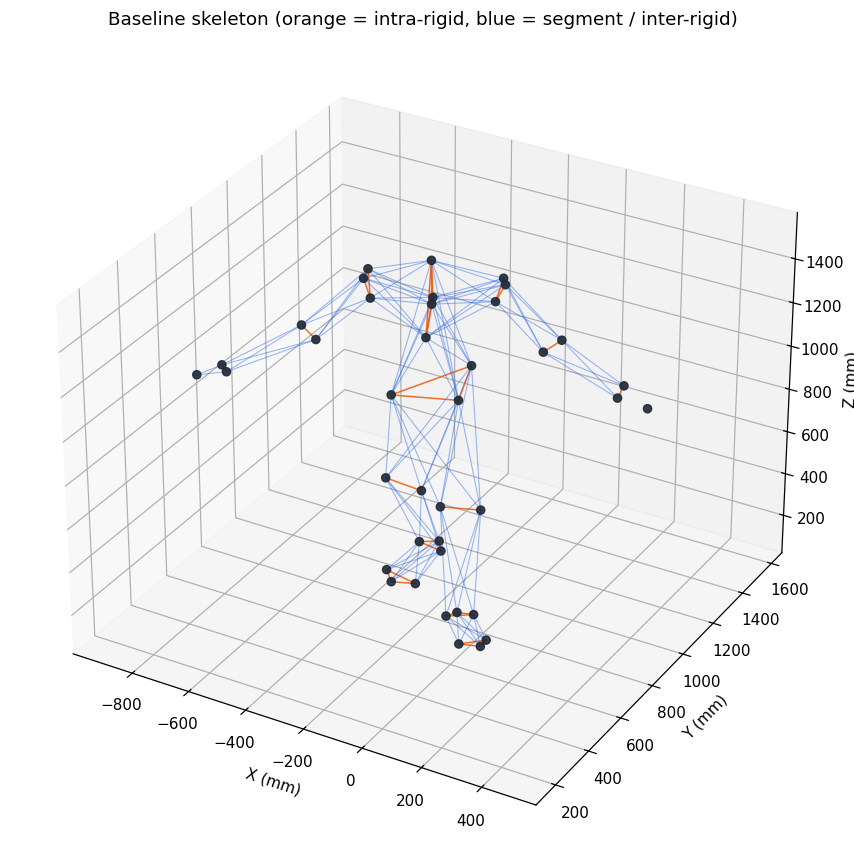

In [32]:
_pts = baseline_pts
fig_sk = plt.figure(figsize=(10, 8))
ax_sk = fig_sk.add_subplot(111, projection="3d")
ax_sk.scatter(_pts[:, 0], _pts[:, 1], _pts[:, 2], c="#1f2937", s=28, alpha=0.9)
for _indices in baseline_groups.values():
    for _ii in range(len(_indices)):
        for _jj in range(_ii + 1, len(_indices)):
            _u, _v = _indices[_ii], _indices[_jj]
            ax_sk.plot(
                [_pts[_u, 0], _pts[_v, 0]],
                [_pts[_u, 1], _pts[_v, 1]],
                [_pts[_u, 2], _pts[_v, 2]],
                color="#ea580c",
                linewidth=1.0,
                alpha=0.85,
            )
for _seg in graph.get("segmentEdgesBetweenRigidBodies", []):
    _ia = baseline_groups.get(_seg["groupA"], [])
    _ib = baseline_groups.get(_seg["groupB"], [])
    for _u in _ia:
        for _v in _ib:
            ax_sk.plot(
                [_pts[_u, 0], _pts[_v, 0]],
                [_pts[_u, 1], _pts[_v, 1]],
                [_pts[_u, 2], _pts[_v, 2]],
                color="#2563eb",
                linewidth=0.7,
                alpha=0.45,
            )
ax_sk.set_title("Baseline skeleton (orange = intra-rigid, blue = segment / inter-rigid)")
ax_sk.set_xlabel("X (mm)")
ax_sk.set_ylabel("Y (mm)")
ax_sk.set_zlabel("Z (mm)")
_max_range = float(np.ptp(_pts, axis=0).max()) / 2.0
if _max_range > 0:
    _mid = _pts.mean(axis=0)
    ax_sk.set_xlim(_mid[0] - _max_range, _mid[0] + _max_range)
    ax_sk.set_ylim(_mid[1] - _max_range, _mid[1] + _max_range)
    ax_sk.set_zlim(_mid[2] - _max_range, _mid[2] + _max_range)
plt.tight_layout()
plt.show()

## 6. Multi-frame tracker (implementation)

This section defines `run_tracker`, which matches the notebook introduction:

- **`reference_position_for_follow`**: For frame `f` and graph marker `i`, walks up to
  `lookback` solved frames — indices `f−1, f−2, …` in the **forward** pass, or `f+1, f+2, …`
  in the **backward** pass — and returns the first non-null `position_by_graph_marker[i]`.
  That 3D point is the anchor for **follow**.

- **`process_frame`**: Builds fresh `raw_index_for_graph` and `graph_marker_pos` for this frame,
  runs the three phases, then copies them into `per_frame[f]`.

**Phase 1 — follow:** For each graph marker, if `reference_position_for_follow` returns a
position, find the closest unused raw point within `reappear_mm`.

**Phase 2 — fingerprint:** Build a cost matrix for unassigned graph markers with at least one
placed neighbour vs unused raw points (`scipy.optimize.linear_sum_assignment`), accept matches
within `tolerance_mm`, repeat until fixed point.

**Phase 3 — rigid-body rescue:** For each rigid group with **no** assignments yet and ≥3
markers, brute-force a raw triangle matching baseline distances for the first three indices;
assign them, then call fingerprint again.

In [33]:
@dataclass
class PerFrameResult:
    raw_index_by_graph_marker: list[Optional[int]]
    position_by_graph_marker: list[Optional[np.ndarray]]


@dataclass
class DiagnosticsPass:
    frames: int = 0
    bootstrap_total: int = 0
    final_total: int = 0
    delta_total: int = 0
    missing_slots: int = 0
    missing_zero_neighbors: int = 0
    missing_with_neighbors: int = 0
    frames_raw_lt_graph_markers: int = 0
    min_raw: float = float("inf")
    max_raw: int = 0
    sum_raw: int = 0


BIG_COST = 1e12  # infeasible (marker, raw) pair for Hungarian


def _compute_cost(
    i: int,
    r: int,
    cur_pts: np.ndarray,
    graph_marker_pos_local: list,
    raw_index_for_graph_local: list,
    orange_neighbors: list[list[DistConstraint]],
    blue_neighbors: list[list[DistConstraint]],
    orange_angles: list[list[AngleConstraint]],
    tolerance_mm: float,
) -> float:
    """Worst constraint error for assigning graph marker ``i`` to raw ``r``, or ``BIG_COST``."""
    max_err = 0.0
    count = 0
    for nb in orange_neighbors[i]:
        if raw_index_for_graph_local[nb.j] is None:
            continue
        d = float(np.linalg.norm(cur_pts[r] - graph_marker_pos_local[nb.j]))
        max_err = max(max_err, abs(d - nb.d0))
        count += 1
    for nb in blue_neighbors[i]:
        if raw_index_for_graph_local[nb.j] is None:
            continue
        d = float(np.linalg.norm(cur_pts[r] - graph_marker_pos_local[nb.j]))
        max_err = max(max_err, abs(d - nb.d0))
        count += 1
    for ang in orange_angles[i]:
        if raw_index_for_graph_local[ang.j] is None or raw_index_for_graph_local[ang.k] is None:
            continue
        ref_j = graph_marker_pos_local[ang.j]
        ref_k = graph_marker_pos_local[ang.k]
        dp = float(np.linalg.norm(cur_pts[r] - ref_j))
        dq = float(np.linalg.norm(cur_pts[r] - ref_k))
        if dp > 0 and dq > 0:
            vp = ref_j - cur_pts[r]
            vq = ref_k - cur_pts[r]
            cos_val = float(np.dot(vp, vq) / (dp * dq))
            cos_val = max(-1.0, min(1.0, cos_val))
            angle = math.acos(cos_val)
            da = abs(angle - ang.angle0)
            ea = da * ((ang.d0p + ang.d0q) / 2)
            max_err = max(max_err, ea)
            count += 1
    if count == 0 or max_err > tolerance_mm:
        return BIG_COST
    return max_err


def run_tracker(
    frames: list[FrameRow],
    baseline_idx: int,
    num_graph_markers: int,
    baseline_pts: np.ndarray,
    baseline_groups: dict[int, list[int]],
    orange_neighbors: list[list[DistConstraint]],
    orange_angles: list[list[AngleConstraint]],
    blue_neighbors: list[list[DistConstraint]],
    *,
    reappear_mm: float = REAPPEAR_MM,
    tolerance_mm: float = TOLERANCE_MM,
    lookback: int = FOLLOW_LOOKBACK_FRAMES,
    log_every: int = 5000,
) -> tuple[list[PerFrameResult], DiagnosticsPass, DiagnosticsPass]:
    """Run forward (baseline → end) and backward (baseline → start) passes.

    Returns ``(per_frame, diag_forward, diag_backward)``. Frames with index ``> baseline``
    are filled only in the forward pass; frames with index ``< baseline`` only in the
    backward pass; the baseline row is seeded once at the start.
    """

    per_frame = [
        PerFrameResult(
            raw_index_by_graph_marker=[None] * num_graph_markers,
            position_by_graph_marker=[None] * num_graph_markers,
        )
        for _ in frames
    ]

    for i in range(num_graph_markers):
        per_frame[baseline_idx].position_by_graph_marker[i] = baseline_pts[i].copy()
        per_frame[baseline_idx].raw_index_by_graph_marker[i] = i

    diag_fwd = DiagnosticsPass()
    diag_bwd = DiagnosticsPass()

    def reference_position_for_follow(f: int, i: int, direction: str) -> Optional[np.ndarray]:
        # Last known 3D position for graph marker i from up to `lookback` already-solved frames.
        for step in range(1, lookback + 1):
            idx = (f - step) if direction == "forward" else (f + step)
            if idx < 0 or idx >= len(frames):
                break
            lp = per_frame[idx].position_by_graph_marker[i]
            if lp is not None:
                return lp
        return None

    def process_frame(f: int, direction: str) -> None:
        """Solve one frame: follow → fingerprint → rigid rescue; store in per_frame[f]."""
        diag = diag_fwd if direction == "forward" else diag_bwd
        cur_pts = frames[f].points
        n = len(cur_pts)
        used_raw: set[int] = set()
        # Per graph marker: assigned raw row index in this frame's point list (None = unknown).
        raw_index_for_graph = [None] * num_graph_markers
        graph_marker_pos: list[Optional[np.ndarray]] = [None] * num_graph_markers

        diag.frames += 1
        diag.min_raw = min(diag.min_raw, n)
        diag.max_raw = max(diag.max_raw, n)
        diag.sum_raw += n
        if n < num_graph_markers:
            diag.frames_raw_lt_graph_markers += 1

        # Phase 1: follow — nearest unused raw within reappear_mm of reference_position_for_follow.
        bootstrap = 0
        for i in range(num_graph_markers):
            prev = reference_position_for_follow(f, i, direction)
            if prev is None:
                continue
            best_r, best_d = -1, float("inf")
            for r in range(n):
                if r in used_raw:
                    continue
                d = float(np.linalg.norm(cur_pts[r] - prev))
                if d < best_d:
                    best_d = d
                    best_r = r
            if best_r >= 0 and best_d <= reappear_mm:
                bootstrap += 1
                raw_index_for_graph[i] = best_r
                graph_marker_pos[i] = cur_pts[best_r].copy()
                used_raw.add(best_r)
        diag.bootstrap_total += bootstrap

        # Phase 2: fingerprint — iterative Hungarian until fixed point.
        def fingerprint_fill() -> None:
            progress = True
            while progress:
                progress = False
                free_markers = []
                for i in range(num_graph_markers):
                    if raw_index_for_graph[i] is not None:
                        continue
                    has_nbr = False
                    for nb in orange_neighbors[i]:
                        if raw_index_for_graph[nb.j] is not None:
                            has_nbr = True
                            break
                    if not has_nbr:
                        for nb in blue_neighbors[i]:
                            if raw_index_for_graph[nb.j] is not None:
                                has_nbr = True
                                break
                    if not has_nbr:
                        for ang in orange_angles[i]:
                            if raw_index_for_graph[ang.j] is not None and raw_index_for_graph[ang.k] is not None:
                                has_nbr = True
                                break
                    if has_nbr:
                        free_markers.append(i)
                if not free_markers:
                    break
                free_raws = [r for r in range(n) if r not in used_raw]
                if not free_raws:
                    break
                nm = len(free_markers)
                nr = len(free_raws)
                cost = np.full((nm, nr), BIG_COST, dtype=np.float64)
                for mi, i in enumerate(free_markers):
                    for ri, r in enumerate(free_raws):
                        cost[mi, ri] = _compute_cost(
                            i, r, cur_pts, graph_marker_pos, raw_index_for_graph,
                            orange_neighbors, blue_neighbors, orange_angles, tolerance_mm,
                        )
                row_ind, col_ind = linear_sum_assignment(cost)
                assigned_this_round = 0
                for mi, ri in zip(row_ind, col_ind):
                    if cost[mi, ri] >= BIG_COST:
                        continue
                    i = free_markers[mi]
                    r = free_raws[ri]
                    raw_index_for_graph[i] = r
                    graph_marker_pos[i] = cur_pts[r].copy()
                    used_raw.add(r)
                    assigned_this_round += 1
                if assigned_this_round > 0:
                    progress = True

        fingerprint_fill()

        # Phase 3: if an entire rigid body is empty, try matching a baseline triangle in raw space.
        for _gid, indices in baseline_groups.items():
            if any(raw_index_for_graph[i] is not None for i in indices):
                continue
            if len(indices) < 3:
                continue
            unassigned = [r for r in range(n) if r not in used_raw]
            i0, i1, i2 = indices[0], indices[1], indices[2]
            d01 = _dist(baseline_pts[i0], baseline_pts[i1])
            d02 = _dist(baseline_pts[i0], baseline_pts[i2])
            d12 = _dist(baseline_pts[i1], baseline_pts[i2])
            found = None
            for a_idx, ra in enumerate(unassigned):
                for b_idx, rb in enumerate(unassigned):
                    if a_idx == b_idx:
                        continue
                    if abs(_dist(cur_pts[ra], cur_pts[rb]) - d01) > tolerance_mm:
                        continue
                    for c_idx, rc in enumerate(unassigned):
                        if c_idx == a_idx or c_idx == b_idx:
                            continue
                        if abs(_dist(cur_pts[ra], cur_pts[rc]) - d02) > tolerance_mm:
                            continue
                        if abs(_dist(cur_pts[rb], cur_pts[rc]) - d12) > tolerance_mm:
                            continue
                        found = (ra, rb, rc)
                        break
                    if found:
                        break
                if found:
                    break
            if found:
                for graph_marker_i, raw_i in zip([i0, i1, i2], found):
                    raw_index_for_graph[graph_marker_i] = raw_i
                    graph_marker_pos[graph_marker_i] = cur_pts[raw_i].copy()
                    used_raw.add(raw_i)
                fingerprint_fill()

        # Per-frame diagnostic tallies (missing slots, neighbour stats).
        assigned_final = sum(1 for x in raw_index_for_graph if x is not None)
        diag.final_total += assigned_final
        diag.delta_total += assigned_final - bootstrap
        for i in range(num_graph_markers):
            if raw_index_for_graph[i] is not None:
                continue
            diag.missing_slots += 1
            has_nbr = False
            for nb in orange_neighbors[i]:
                if raw_index_for_graph[nb.j] is not None:
                    has_nbr = True
                    break
            if not has_nbr:
                for nb in blue_neighbors[i]:
                    if raw_index_for_graph[nb.j] is not None:
                        has_nbr = True
                        break
            if has_nbr:
                diag.missing_with_neighbors += 1
            else:
                diag.missing_zero_neighbors += 1

        per_frame[f].raw_index_by_graph_marker = raw_index_for_graph
        per_frame[f].position_by_graph_marker = graph_marker_pos

    # Forward: increasing frame index from baseline+1 to end.
    print("Forward pass …")
    t0 = time.perf_counter()
    for f in range(baseline_idx + 1, len(frames)):
        process_frame(f, "forward")
        if log_every > 0 and (f - baseline_idx) % log_every == 0:
            elapsed = time.perf_counter() - t0
            fps = (f - baseline_idx) / elapsed if elapsed > 0 else 0
            print(f"  frame {f:>7,} / {len(frames):,}  ({fps:,.0f} frames/s)")
    fwd_time = time.perf_counter() - t0
    fwd_n = max(1, len(frames) - baseline_idx - 1)
    print(f"  Forward done: {fwd_n:,} frames in {fwd_time:.2f}s ({fwd_n / fwd_time:,.0f} frames/s)")

    # Backward: decreasing index from baseline-1 to 0 (reference_position_for_follow uses later frames).
    print("Backward pass …")
    t1 = time.perf_counter()
    for f in range(baseline_idx - 1, -1, -1):
        process_frame(f, "backward")
        if log_every > 0 and (baseline_idx - f) % log_every == 0:
            elapsed = time.perf_counter() - t1
            fps = (baseline_idx - f) / elapsed if elapsed > 0 else 0
            print(f"  frame {f:>7,} / 0  ({fps:,.0f} frames/s)")
    bwd_time = time.perf_counter() - t1
    bwd_n = max(1, baseline_idx)
    print(f"  Backward done: {bwd_n:,} frames in {bwd_time:.2f}s ({bwd_n / bwd_time:,.0f} frames/s)")

    return per_frame, diag_fwd, diag_bwd

## 7. Run the tracker

Executes both passes on the loaded clip. On ~100k frames, pure Python is typically on the
order of **minutes**; use `MAX_FRAMES` below for a shorter subset while developing.

In [ ]:
MAX_FRAMES = 0  # 0 = all frames; e.g. 5000 for quicker runs

if MAX_FRAMES > 0:
    frames_subset = frames[:MAX_FRAMES]
    _baseline = min(baseline_idx, len(frames_subset) - 1)
    print(f"⚠ Using first {MAX_FRAMES} frames (of {len(frames):,}) for speed. Set MAX_FRAMES=0 for full run.")
else:
    frames_subset = frames
    _baseline = baseline_idx

wall_t0 = time.perf_counter()
per_frame, diag_fwd, diag_bwd = run_tracker(
    frames_subset, _baseline, num_graph_markers, baseline_pts, baseline_groups,
    orange_neighbors, orange_angles, blue_neighbors,
    reappear_mm=REAPPEAR_MM,
    tolerance_mm=TOLERANCE_MM,
    lookback=FOLLOW_LOOKBACK_FRAMES,
)
wall_total = time.perf_counter() - wall_t0
print(f"\nTotal wall time: {wall_total:.2f}s  ({len(frames_subset) / wall_total:,.0f} frames/s)")

Forward pass …
  frame   5,567 / 106,583  (964 frames/s)
  frame  10,567 / 106,583  (968 frames/s)
  frame  15,567 / 106,583  (948 frames/s)
  frame  20,567 / 106,583  (917 frames/s)
  frame  25,567 / 106,583  (902 frames/s)
  frame  30,567 / 106,583  (892 frames/s)
  frame  35,567 / 106,583  (884 frames/s)
  frame  40,567 / 106,583  (874 frames/s)
  frame  45,567 / 106,583  (873 frames/s)
  frame  50,567 / 106,583  (869 frames/s)
  frame  55,567 / 106,583  (869 frames/s)
  frame  60,567 / 106,583  (869 frames/s)
  frame  65,567 / 106,583  (868 frames/s)
  frame  70,567 / 106,583  (860 frames/s)
  frame  75,567 / 106,583  (852 frames/s)
  frame  80,567 / 106,583  (843 frames/s)


## 8. Compute per-frame analytics

For every frame we compute:
- **Assignment rate** — fraction of graph markers assigned
- **Raw point count** — how many 3D detections were in the TSV row
- **Orange edge length error** — mean deviation from baseline intra-rigid distances
- **Blue edge length error** — mean deviation from baseline inter-rigid distances
- **Orange angle error** — mean deviation from baseline intra-rigid angles
- **Edge flagged** — whether the mean error exceeds `edge_warning_threshold_mm`

In [ ]:
@dataclass
class FrameStats:
    frame_index: int
    file_frame: int
    time_sec: float
    raw_point_count: int
    matched: int
    missing: int
    unassigned_raw: int
    rate: float
    is_baseline: bool
    orange_len_err: Optional[float]
    orange_ang_err: Optional[float]
    blue_len_err: Optional[float]
    edge_flagged: bool


def compute_analytics(
    frames: list[FrameRow],
    per_frame: list[PerFrameResult],
    baseline_idx: int,
    num_graph_markers: int,
    baseline_pts: np.ndarray,
    graph: dict,
    edge_warn_th: Optional[float] = EDGE_WARNING_THRESHOLD_MM,
) -> list[FrameStats]:
    """Compute per-frame assignment and edge-quality metrics."""

    groups = build_baseline_indices_by_group(graph)

    # Precompute edge pairs for analytics
    a_orange_edges: list[tuple[int, int, float]] = []
    a_orange_angles: list[tuple[int, int, int, float, float, float]] = []
    a_blue_edges: list[tuple[int, int, float]] = []

    for indices in groups.values():
        for i in range(len(indices)):
            for j in range(i + 1, len(indices)):
                u, v = indices[i], indices[j]
                a_orange_edges.append((u, v, _dist(baseline_pts[u], baseline_pts[v])))
        for i in range(len(indices)):
            for j in range(len(indices)):
                for k in range(j + 1, len(indices)):
                    if i == j or i == k:
                        continue
                    u, v1, v2 = indices[i], indices[j], indices[k]
                    d0p = _dist(baseline_pts[u], baseline_pts[v1])
                    d0q = _dist(baseline_pts[u], baseline_pts[v2])
                    if d0p > 0 and d0q > 0:
                        p = baseline_pts[v1] - baseline_pts[u]
                        q = baseline_pts[v2] - baseline_pts[u]
                        cos0 = float(np.dot(p, q) / (d0p * d0q))
                        cos0 = max(-1.0, min(1.0, cos0))
                        a_orange_angles.append((u, v1, v2, math.acos(cos0), d0p, d0q))

    for seg in graph.get("segmentEdgesBetweenRigidBodies", []):
        ia = groups.get(seg["groupA"], [])
        ib = groups.get(seg["groupB"], [])
        for u in ia:
            for v in ib:
                a_blue_edges.append((u, v, _dist(baseline_pts[u], baseline_pts[v])))

    out: list[FrameStats] = []
    for fi, row in enumerate(frames):
        pf = per_frame[fi]
        rfr = pf.raw_index_by_graph_marker
        matched = sum(1 for x in rfr if x is not None)
        missing = num_graph_markers - matched
        used = {r for r in rfr if r is not None}
        unassigned_raw = sum(1 for j in range(len(row.points)) if j not in used)
        rate = (matched / num_graph_markers * 100) if num_graph_markers > 0 else 0.0

        o_len_sum, o_len_n = 0.0, 0
        o_ang_sum, o_ang_n = 0.0, 0
        b_len_sum, b_len_n = 0.0, 0

        cur = row.points
        for u, v, d0 in a_orange_edges:
            ru, rv = rfr[u], rfr[v]
            if ru is not None and rv is not None:
                o_len_sum += abs(_dist(cur[ru], cur[rv]) - d0)
                o_len_n += 1

        for u, v1, v2, ang0, d0p, d0q in a_orange_angles:
            ru, rv1, rv2 = rfr[u], rfr[v1], rfr[v2]
            if ru is not None and rv1 is not None and rv2 is not None:
                d1 = _dist(cur[ru], cur[rv1])
                d2 = _dist(cur[ru], cur[rv2])
                if d1 > 0 and d2 > 0:
                    p = cur[rv1] - cur[ru]
                    q = cur[rv2] - cur[ru]
                    cos_v = float(np.dot(p, q) / (d1 * d2))
                    cos_v = max(-1.0, min(1.0, cos_v))
                    o_ang_sum += abs(math.acos(cos_v) - ang0)
                    o_ang_n += 1

        for u, v, d0 in a_blue_edges:
            ru, rv = rfr[u], rfr[v]
            if ru is not None and rv is not None:
                b_len_sum += abs(_dist(cur[ru], cur[rv]) - d0)
                b_len_n += 1

        o_len = (o_len_sum / o_len_n) if o_len_n > 0 else None
        o_ang = (o_ang_sum / o_ang_n) if o_ang_n > 0 else None
        b_len = (b_len_sum / b_len_n) if b_len_n > 0 else None

        flagged = False
        if edge_warn_th is not None and fi != baseline_idx:
            if o_len is not None and o_len > edge_warn_th:
                flagged = True
            if b_len is not None and b_len > edge_warn_th:
                flagged = True

        out.append(FrameStats(
            frame_index=fi, file_frame=row.frame, time_sec=row.time,
            raw_point_count=len(row.points),
            matched=matched, missing=missing, unassigned_raw=unassigned_raw,
            rate=rate, is_baseline=(fi == baseline_idx),
            orange_len_err=o_len, orange_ang_err=o_ang, blue_len_err=b_len,
            edge_flagged=flagged,
        ))
    return out


print("Computing per-frame analytics …")
t0 = time.perf_counter()
frame_stats = compute_analytics(
    frames_subset, per_frame, _baseline, num_graph_markers, baseline_pts, graph,
    edge_warn_th=EDGE_WARNING_THRESHOLD_MM,
)
t_analytics = time.perf_counter() - t0
print(f"  Done in {t_analytics:.2f}s")

## 9. Summary statistics

In [ ]:
non_baseline = [s for s in frame_stats if not s.is_baseline]
mean_rate = np.mean([s.rate for s in non_baseline]) if non_baseline else 0
min_rate_s = min(non_baseline, key=lambda s: s.rate) if non_baseline else None
full_assign = sum(1 for s in non_baseline if s.missing == 0)
total_misses = sum(s.missing for s in non_baseline)
total_unassigned = sum(s.unassigned_raw for s in non_baseline)
flagged = sum(1 for s in non_baseline if s.edge_flagged)

o_errs = [s.orange_len_err for s in non_baseline if s.orange_len_err is not None]
b_errs = [s.blue_len_err for s in non_baseline if s.blue_len_err is not None]
a_errs = [s.orange_ang_err for s in non_baseline if s.orange_ang_err is not None]

print("=" * 60)
print("TRACKING SUMMARY")
print("=" * 60)
print(f"Frames total / tracked  : {len(frames_subset):,} / {len(non_baseline):,}")
print(f"Graph markers           : {num_graph_markers}")
print(f"Mean assignment rate    : {mean_rate:.2f}%")
if min_rate_s:
    print(f"Min  assignment rate    : {min_rate_s.rate:.2f}% "
          f"(frame {min_rate_s.frame_index}, file #{min_rate_s.file_frame})")
print(f"Frames fully assigned   : {full_assign:,} / {len(non_baseline):,}")
print(f"Total graph-marker misses: {total_misses:,}")
print(f"Total unassigned raw    : {total_unassigned:,}")
if o_errs:
    print(f"Mean orange edge err    : {np.mean(o_errs):.2f} mm")
if a_errs:
    print(f"Mean orange angle err   : {np.degrees(np.mean(a_errs)):.2f}°")
if b_errs:
    print(f"Mean blue edge err      : {np.mean(b_errs):.2f} mm")
print(f"Frames edge-flagged     : {flagged:,} / {len(non_baseline):,}  "
      f"(threshold {EDGE_WARNING_THRESHOLD_MM} mm)")
print(f"Wall time               : {wall_total:.2f}s  "
      f"({len(frames_subset) / wall_total:,.0f} frames/s)")
print("=" * 60)

## 10. Chart — Raw detections vs graph markers assigned

**Green:** raw 3D points in the TSV row. **Blue:** graph markers assigned to a raw point
this frame. **Gray dashed:** total graph markers in the skeleton (`num_graph_markers`).

In [ ]:
times = [s.time_sec for s in frame_stats]
raw_counts = [s.raw_point_count for s in frame_stats]
matched_counts = [s.matched for s in frame_stats]

fig, ax = plt.subplots()
ax.plot(times, raw_counts, color="#16a34a", linewidth=0.6, label="Raw detections (TSV)")
ax.plot(times, matched_counts, color="#3b82f6", linewidth=0.6, label="Graph markers assigned")
ax.axhline(num_graph_markers, color="#a1a1aa", linestyle="--", linewidth=0.7, label=f"Graph marker count ({num_graph_markers})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Count")
ax.set_title("Raw detections vs graph markers assigned")
ax.legend(fontsize=8)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 11. Chart — Assignment rate (accuracy) over time

Percentage of graph markers assigned each frame. 100% means every skeleton marker has a
raw detection; drops indicate occlusion or tracking loss.

In [ ]:
rates = [s.rate if not s.is_baseline else None for s in frame_stats]

fig, ax = plt.subplots()
valid_t = [t for t, r in zip(times, rates) if r is not None]
valid_r = [r for r in rates if r is not None]
ax.plot(valid_t, valid_r, color="#2563eb", linewidth=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("% assigned")
ax.set_title("Assignment rate (accuracy) over time")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 12. Chart — Edge length errors over time

Mean deviation (mm) of assigned marker distances from their baseline values.
- **Orange** = intra-rigid-body edges (should be near-zero for a truly rigid body)
- **Blue** = inter-rigid / hinge edges (larger variation expected due to joint motion)
- **Red dashed** = edge warning threshold

In [ ]:
orange_e = [s.orange_len_err if not s.is_baseline else None for s in frame_stats]
blue_e = [s.blue_len_err if not s.is_baseline else None for s in frame_stats]

fig, ax = plt.subplots()
t_o = [t for t, v in zip(times, orange_e) if v is not None]
v_o = [v for v in orange_e if v is not None]
t_b = [t for t, v in zip(times, blue_e) if v is not None]
v_b = [v for v in blue_e if v is not None]

ax.plot(t_o, v_o, color="#ea580c", linewidth=0.5, label="Orange (intra-rigid)")
ax.plot(t_b, v_b, color="#2563eb", linewidth=0.5, label="Blue (inter-rigid)")
if EDGE_WARNING_THRESHOLD_MM is not None:
    ax.axhline(EDGE_WARNING_THRESHOLD_MM, color="#dc2626", linestyle="--", linewidth=0.7,
               label=f"Warn threshold ({EDGE_WARNING_THRESHOLD_MM} mm)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mean edge length error (mm)")
ax.set_title("Edge length errors over time")
ax.legend(fontsize=8)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 13. Chart — Orange angle error over time

Mean angular deviation (degrees) of intra-rigid-body marker triangles from their
baseline geometry. Spikes indicate identity swaps or deformation.

In [ ]:
ang_e = [
    (math.degrees(s.orange_ang_err) if s.orange_ang_err is not None else None)
    if not s.is_baseline else None
    for s in frame_stats
]

fig, ax = plt.subplots()
t_a = [t for t, v in zip(times, ang_e) if v is not None]
v_a = [v for v in ang_e if v is not None]
ax.plot(t_a, v_a, color="#9333ea", linewidth=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mean angle error (°)")
ax.set_title("Orange (intra-rigid) angle error over time")
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 14. Pass diagnostics

Printed stats for the forward and backward passes: average follow assignments, final
counts, how much fingerprint/rescue added beyond follow, and missing-slot breakdown.

In [ ]:
def print_diagnostics(label: str, d: DiagnosticsPass) -> None:
    n = max(1, d.frames)
    print(f"\n--- {label} ({d.frames:,} frames) ---")
    print(f"  Avg carry-forward (follow)  : {d.bootstrap_total / n:.2f}")
    print(f"  Avg final assigned          : {d.final_total / n:.2f}")
    print(f"  Avg fingerprint/rescue fill : {d.delta_total / n:.2f}")
    miss = d.missing_slots
    if miss > 0:
        pct0 = 100 * d.missing_zero_neighbors / miss
        pctN = 100 * d.missing_with_neighbors / miss
        print(f"  Missing graph-marker slots (Σ)   : {miss:,}")
        print(f"    → zero neighbors          : {d.missing_zero_neighbors:,} ({pct0:.1f}%)")
        print(f"    → ≥1 neighbor, still lost : {d.missing_with_neighbors:,} ({pctN:.1f}%)")
    else:
        print(f"  Missing graph-marker slots (Σ)   : 0")
    print(f"  Frames with raw count < graph-marker count : {d.frames_raw_lt_graph_markers:,}")
    if d.frames > 0 and math.isfinite(d.min_raw):
        print(f"  Raw count range             : {d.min_raw} – {d.max_raw} "
              f"(mean {d.sum_raw / n:.1f})")


print_diagnostics("Forward pass", diag_fwd)
print_diagnostics("Backward pass", diag_bwd)

### Tips

Adjust `REAPPEAR_MM`, `TOLERANCE_MM`, `FOLLOW_LOOKBACK_FRAMES`, and
`EDGE_WARNING_THRESHOLD_MM` in **§1** to tune behaviour; use `MAX_FRAMES` in **§7** for
faster experiments on a prefix of the clip.